1: Importación de Librerías
Explicación: Importamos las herramientas de análisis de datos (pandas, numpy), visualización (matplotlib, seaborn) y las librerías necesarias de scikit-learn para dividir el dataset y realizar el preprocesamiento básico de texto.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Herramientas de Scikit-Learn para NLP y Modelado
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Configuración de estilo gráfico
sns.set_theme(style="whitegrid")
%matplotlib inline

Carga de Datos y Eliminación de Índice Irrelevante
Cambio/Modificación: Se elimina la columna Unnamed: 0 inmediatamente después de cargar los datos. Esta columna contenía un índice numérico único por fila que impedía detectar duplicados reales entre registros.

In [2]:
# Carga del dataset (asegúrate de que la ruta o el nombre del archivo sea el correcto en tu Colab)
# Si lo subes a Colab directamente:
archivo = "Online_Courses.csv"

df = pd.read_csv(archivo)

print("Dataset cargado correctamente.\n")

print(f"Número de registros : {df.shape[0]}")
print(f"Número de columnas  : {df.shape[1]}")

# Eliminamos la columna de índice irrelevante si existe
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print(f"Dimensiones iniciales del dataset: {df.shape}")
df.head()

Dataset cargado correctamente.

Número de registros : 8092
Número de columnas  : 45
Dimensiones iniciales del dataset: (8092, 44)


,Title,URL,Short Intro,Category,Sub-Category,Course Type,Language,Subtitle Languages,Skills,Instructors,...,Course Short Intro,Weekly study,Premium course,What's include,Rank,Created by,Program,Number of ratings,Price,COURSE CATEGORIES
0,Machine Learning Specialization,https://www.coursera.org/specializations/machi...,#BreakIntoAI with Machine Learning Specializat...,Data Science,Machine Learning,Specialization,English,Subtitles: English,"Decision Trees, Artificial Neural Network, Log...","Andrew Ng ,Eddy Shyu ,Aarti Bagul ,Geoff Ladwig ,",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Introduction to Data Science Specialization,https://www.coursera.org/specializations/intro...,Launch your career in data science. Gain found...,Data Science,Data Analysis,Specialization,English,"Subtitles: English, Arabic, French, Portuguese...","Data Science, Relational Database Management S...","Rav Ahuja ,Alex Aklson ,Aije Egwaikhide ,Svetl...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Data Science Fundamentals with Python and SQL ...,https://www.coursera.org/specializations/data-...,Build the Foundation for your Data Science car...,Data Science,Data Analysis,Specialization,English,"Subtitles: English, Arabic, French, Portuguese...","Data Science, Github, Python Programming, Jupy...","Aije Egwaikhide ,Svetlana Levitan ,Romeo Kienz...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Key Technologies for Business Specialization,https://www.coursera.org/specializations/key-t...,Get Ahead with Key Business Technologies. Gain...,Business,Business Essentials,Specialization,English,"Subtitles: English, Arabic, French, Portuguese...","Data Science, Artificial Intelligence (AI), Bu...","Rav Ahuja ,Alex Aklson ,",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Deep Learning Specialization,https://www.coursera.org/specializations/deep-...,Become a Machine Learning expert. Master the f...,Data Science,Machine Learning,Specialization,English,"Subtitles: English, Chinese (Traditional), Ara...","Artificial Neural Network, Convolutional Neura...","Andrew Ng ,Kian Katanforoosh ,Younes Bensouda ...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


3: Limpieza de Duplicados
Cambio/Modificación: Ahora que eliminamos la columna de índice numérico, buscamos y eliminamos cursos duplicados basándonos en la combinación del título (Title) y la URL (URL).

In [3]:
# Verificación y eliminación de duplicados reales
duplicados = df.duplicated(subset=['Title', 'URL']).sum()
print(f"Número de filas duplicadas encontradas: {duplicados}")

if duplicados > 0:
    df = df.drop_duplicates(subset=['Title', 'URL']).reset_index(drop=True)
    print(f"Dimensiones tras eliminar duplicados: {df.shape}")

Número de filas duplicadas encontradas: 2817
Dimensiones tras eliminar duplicados: (5275, 44)


Manejo de Valores Nulos (Depuración Crítica)
Cambio/Modificación: Como la columna objetivo Category presenta más del 65% de valores nulos, filtramos el DataFrame para conservar solo las filas que tengan una categoría válida. Asimismo, rellenamos con texto vacío cualquier valor nulo en las columnas de texto descriptivo (Title y Short Intro).

In [4]:
# Revisión de nulos por columna
print("--- Valores nulos por columna antes de limpiar ---")
print(df.isnull().sum())

# 1. Filtrar registros sin variable objetivo (Category)
df_clean = df.dropna(subset=['Category']).copy()

# 2. Rellenar nulos en variables de texto secundarias
df_clean['Title'] = df_clean['Title'].fillna('')
df_clean['Short Intro'] = df_clean['Short Intro'].fillna('')

print("\n--- Estado tras la limpieza de nulos ---")
print(f"Registros listos para entrenamiento: {df_clean.shape[0]} de {df.shape[0]}")

--- Valores nulos por columna antes de limpiar ---
Title                       0
URL                         0
Short Intro                52
Category                 2456
Sub-Category             2456
Course Type              2456
Language                 2456
Subtitle Languages       2473
Skills                   3181
Instructors              2467
Rating                   2538
Number of viewers        2580
Duration                  148
Site                        0
Program Type             4998
Courses                  3148
Level                    5094
Number of Reviews        5233
Unique Projects          5275
Prequisites              4999
What you learn           5002
Related Programs         5195
Monthly access           5182
6-Month access           5273
4-Month access           5241
3-Month access           5250
5-Month access           5273
2-Month access           5265
School                   5009
Topics related to CRM    3297
ExpertTracks             3244
FAQs               

5: Visualización de Categorías (Con solución para fuentes UTF-8)
Cambio/Modificación: Para solucionar la advertencia UserWarning: Glyph missing provocada por caracteres asiáticos en algunas categorías, usamos expresiones regulares para limpiar/filtrar el texto y mostramos un gráfico horizontal de barras de las categorías principales.

/tmp/ipykernel_1912/2642569106.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, y='Category_Clean', order=order, palette='viridis')


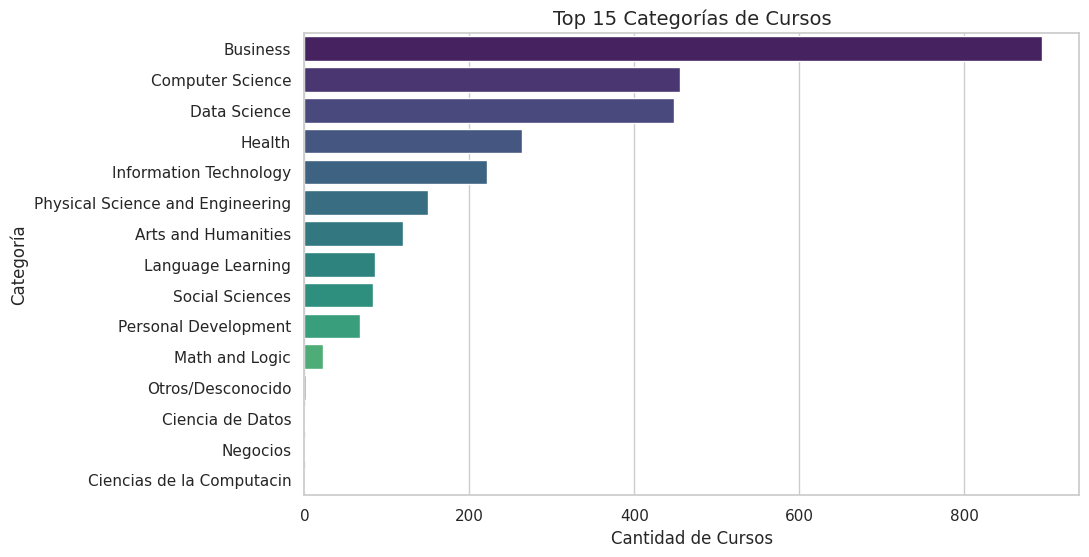

In [5]:
# Limpieza rápida de caracteres no ASCII en la visualización para evitar fallos de fuentes
df_clean['Category_Clean'] = df_clean['Category'].apply(lambda x: re.sub(r'[^\x00-\x7F]+', '', str(x)).strip())
# Si alguna categoría quedó vacía tras la limpieza, la nombraremos 'Otros / Desconocido'
df_clean['Category_Clean'] = df_clean['Category_Clean'].replace('', 'Otros/Desconocido')

plt.figure(figsize=(10, 6))
order = df_clean['Category_Clean'].value_counts().head(15).index
sns.countplot(data=df_clean, y='Category_Clean', order=order, palette='viridis')

plt.title('Top 15 Categorías de Cursos', fontsize=14)
plt.xlabel('Cantidad de Cursos')
plt.ylabel('Categoría')
plt.show()

6: Construcción del Texto de Entrada ($X$) y Variable Objetivo ($y$)Explicación: Para mejorar la precisión de los modelos de PNL, combinamos el título (Title) y la breve introducción (Short Intro) en una única característica de texto llamada Full_Text. Definimos Full_Text como nuestra variable predictora $X$ y Category como nuestra etiqueta $y$.

In [6]:
# Combinación de características de texto
df_clean['Full_Text'] = df_clean['Title'] + " " + df_clean['Short Intro']

# Definición de X e y
X = df_clean['Full_Text']
y = df_clean['Category_Clean']

print(f"Ejemplo de texto de entrada (X):\n'{X.iloc[0]}'\n")
print(f"Ejemplo de etiqueta (y):\n'{y.iloc[0]}'")

Ejemplo de texto de entrada (X):
'Machine Learning Specialization #BreakIntoAI with Machine Learning Specialization. Master fundamental AI concepts and develop practical machine learning skills in the beginner-friendly, 3-course program by AI visionary Andrew Ng'

Ejemplo de etiqueta (y):
'Data Science'


7: División del Dataset en Entrenamiento y Prueba
Explicación: Dividimos el conjunto de datos limpio (80% para entrenamiento, 20% para evaluación). Se incluye el parámetro stratify=y para asegurar que las proporciones de cada categoría se mantengan balanceadas tanto en el conjunto de entrenamiento como en el de prueba.

In [8]:
import numpy as np

# 1. Identificar las categorías con una única instancia
category_counts = y.value_counts()
single_member_categories = category_counts[category_counts == 1].index

# 2. Filtrar X e y para excluir estas categorías
# Obtener los índices de las filas a conservar (donde la categoría NO está en single_member_categories)
indices_to_keep = y[~y.isin(single_member_categories)].index

X_filtered = X.loc[indices_to_keep]
y_filtered = y.loc[indices_to_keep]

print(f"Número original de muestras: {len(X)}")
print(f"Número de categorías con un único miembro: {len(single_member_categories)}")
print(f"Muestras restantes después de eliminar categorías de un solo miembro: {len(X_filtered)}\n")

# 3. Realizar la división con los datos filtrados
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered,
    y_filtered,
    test_size=0.20,
    random_state=42,
    stratify=y_filtered # Ahora la estratificación debería funcionar
)

print(f"Tamaño de Entrenamiento (Train): {X_train.shape[0]} muestras")
print(f"Tamaño de Prueba (Test): {X_test.shape[0]} muestras")

Número original de muestras: 2819
Número de categorías con un único miembro: 5
Muestras restantes después de eliminar categorías de un solo miembro: 2814

Tamaño de Entrenamiento (Train): 2251 muestras
Tamaño de Prueba (Test): 563 muestras


8: Vectorización del Texto (TF-IDF)
Explicación: Convertimos el texto en una representación numérica matricial utilizando TfidfVectorizer (frecuencia de término - frecuencia inversa de documento), eliminando palabras comunes en inglés (stopwords).

In [9]:
# Inicializar vectorizador borrando palabras vacías (stopwords) en inglés
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

# Ajustar y transformar datos de entrenamiento
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transformar datos de prueba
X_test_tfidf = vectorizer.transform(X_test)

print(f"Dimensiones de la matriz TF-IDF de entrenamiento: {X_train_tfidf.shape}")
print("¡El conjunto de datos está completamente preparado para entrenar modelos de Machine Learning!")

Dimensiones de la matriz TF-IDF de entrenamiento: (2251, 5000)
¡El conjunto de datos está completamente preparado para entrenar modelos de Machine Learning!


9: Entrenamiento del Modelo Base (Naive Bayes)
Explicación: Para problemas de clasificación de texto, Multinomial Naive Bayes es el algoritmo estándar como punto de partida (baseline) debido a su rapidez y buen rendimiento con matrices dispersas de alta dimensión.

In [10]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. Inicializar y entrenar el modelo
model_nb = MultinomialNB()
model_nb.fit(X_train_tfidf, y_train)

# 2. Predicciones en el conjunto de prueba
y_pred_nb = model_nb.predict(X_test_tfidf)

# 3. Evaluación inicial
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"Exactitud (Accuracy) del modelo Naive Bayes: {accuracy_nb * 100:.2f}%\n")

Exactitud (Accuracy) del modelo Naive Bayes: 64.12%



10: Evaluación Detallada del Modelo
Explicación: La exactitud simple (accuracy) no es suficiente si hay clases desbalanceadas. Generamos el reporte de clasificación para observar la precisión, recall y F1-score por cada categoría, así como la matriz de confusión.

--- Reporte de Clasificación (Naive Bayes) ---
                                  precision    recall  f1-score   support

             Arts and Humanities       1.00      0.12      0.22        24
                        Business       0.54      0.97      0.69       179
                Computer Science       0.80      0.69      0.74        91
                    Data Science       0.70      0.86      0.77        90
                          Health       0.95      0.40      0.56        53
          Information Technology       0.94      0.34      0.50        44
               Language Learning       0.00      0.00      0.00        17
                  Math and Logic       0.00      0.00      0.00         4
            Personal Development       0.00      0.00      0.00        14
Physical Science and Engineering       1.00      0.27      0.42        30
                 Social Sciences       0.00      0.00      0.00        17

                        accuracy                           0.64

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


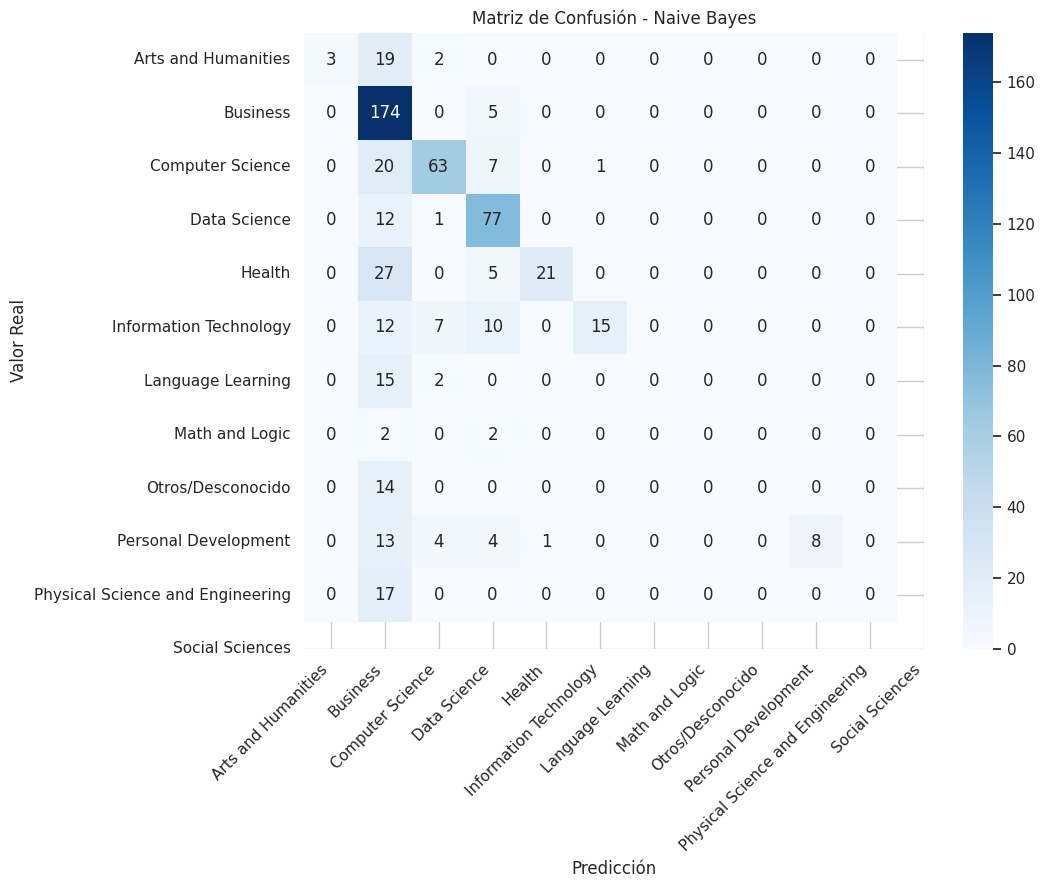

In [11]:
# Reporte de métricas por categoría
print("--- Reporte de Clasificación (Naive Bayes) ---")
print(classification_report(y_test, y_pred_nb))

# Matriz de Confusión
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model_nb.classes_,
            yticklabels=model_nb.classes_)

plt.title('Matriz de Confusión - Naive Bayes')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.xticks(rotation=45, ha='right')
plt.show()

11: Comparación con un Modelo Avanzado (Logistic Regression / SVM)
Explicación: Para comprobar si podemos mejorar los resultados del baseline, entrenamos un segundo modelo con Regresión Logística, que suele desempeñarse muy bien en tareas de PNL con representaciones TF-IDF.

In [12]:
from sklearn.linear_model import LogisticRegression

# 1. Entrenar Regresión Logística
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train_tfidf, y_train)

# 2. Evaluar
y_pred_lr = model_lr.predict(X_test_tfidf)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print(f"Exactitud (Accuracy) Naive Bayes: {accuracy_nb * 100:.2f}%")
print(f"Exactitud (Accuracy) Regresión Logística: {accuracy_lr * 100:.2f}%")

Exactitud (Accuracy) Naive Bayes: 64.12%
Exactitud (Accuracy) Regresión Logística: 74.78%


12: Prueba con Nuevos Datos (Inferencia / Predicción en tiempo real)
Explicación: Simulamos el uso real del modelo en producción pasando un título y una descripción de un curso nuevo que el modelo no haya visto jamás.

In [13]:
def predecir_categoria_curso(titulo, descripcion, modelo, vectorizador):
    # 1. Combinar y estructurar el texto
    texto_nuevo = f"{titulo} {descripcion}"

    # 2. Transformar el texto con el MISMO vectorizador TF-IDF
    texto_tfidf = vectorizador.transform([texto_nuevo])

    # 3. Predecir la categoría
    prediccion = modelo.predict(texto_tfidf)[0]

    # 4. Obtener la probabilidad asignada a la clase ganadora
    probabilidades = modelo.predict_proba(texto_tfidf)
    confianza = np.max(probabilidades) * 100

    return prediccion, confianza

# Ejemplo de prueba con un curso hipotético:
nuevo_titulo = "Python Programming for Data Science and Machine Learning"
nueva_intro = "Learn how to use Pandas, NumPy, and Scikit-Learn to build predictive models from scratch."

categoria_predicha, nivel_confianza = predecir_categoria_curso(
    nuevo_titulo, nueva_intro, model_lr, vectorizer
)

print(f"Curso de prueba: '{nuevo_titulo}'")
print(f"Categoría Predicha: {categoria_predicha}")
print(f"Nivel de Confianza: {nivel_confianza:.2f}%")

Curso de prueba: 'Python Programming for Data Science and Machine Learning'
Categoría Predicha: Data Science
Nivel de Confianza: 68.99%


Resumen del Flujo de Trabajo Completo
Carga y Limpieza: Eliminar variables irrelevantes (Unnamed: 0), gestionar nulos en Category e imputar vacíos en texto.

Preprocesamiento: Unificar campos de texto (Title + Short Intro).

Vectorización: Extraer características numéricas usando TfidfVectorizer.

Entrenamiento: Ajustar algoritmos de clasificación (Naive Bayes, Logistic Regression).

Evaluación: Medir métricas de rendimiento con datos no vistos (Test Set).

Inferencia: Construir una función para clasificar nuevos textos ingresados por el usuario.

13: Validación Cruzada EstratificadaExplicación: Construimos un Pipeline que integra la vectorización y el modelo en un solo objeto. Evaluamos tanto Naive Bayes como Regresión Logística con una validación cruzada de 5 pliegues ($K=5$).

In [14]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
import numpy as np

# 1. Definir la estrategia de validación cruzada (5 pliegues estratificados)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Crear Pipelines para cada modelo
pipeline_nb = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=5000)),
    ('clf', MultinomialNB())
])

pipeline_lr = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=5000)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# 3. Ejecutar Cross-Validation en todo el conjunto de datos limpio (X, y)
scores_nb = cross_val_score(pipeline_nb, X, y, cv=skf, scoring='accuracy', n_jobs=-1)
scores_lr = cross_val_score(pipeline_lr, X, y, cv=skf, scoring='accuracy', n_jobs=-1)

# 4. Mostrar Resultados
print("=== RESULTADOS DE VALIDACIÓN CRUZADA (K=5) ===")
print(f"Naive Bayes - Accuracy por fold: {np.round(scores_nb, 4)}")
print(f"Naive Bayes - Promedio: {scores_nb.mean() * 100:.2f}% (+/- {scores_nb.std() * 100:.2f}%)\n")

print(f"Regresión Logística - Accuracy por fold: {np.round(scores_lr, 4)}")
print(f"Regresión Logística - Promedio: {scores_lr.mean() * 100:.2f}% (+/- {scores_lr.std() * 100:.2f}%)")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


=== RESULTADOS DE VALIDACIÓN CRUZADA (K=5) ===
Naive Bayes - Accuracy por fold: [0.6489 0.6348 0.656  0.6525 0.6554]
Naive Bayes - Promedio: 64.95% (+/- 0.78%)

Regresión Logística - Accuracy por fold: [0.7766 0.7606 0.7766 0.7695 0.7389]
Regresión Logística - Promedio: 76.44% (+/- 1.41%)


14: Visualización de la Estabilidad de los Modelos
Explicación: Graficamos los resultados obtenidos en cada uno de los 5 pliegues para comparar de forma visual cuál de los dos modelos es más estable y consistente a través de diferentes subconjuntos de datos.

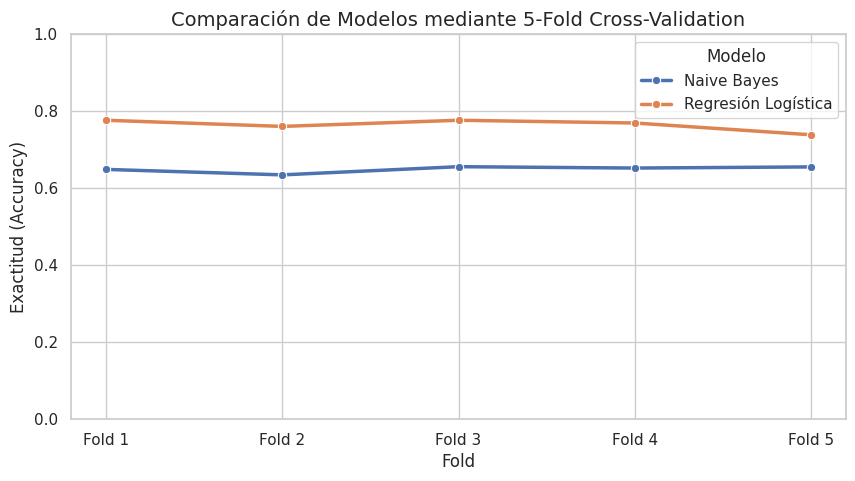

In [15]:
# Crear un DataFrame con los resultados
df_cv = pd.DataFrame({
    'Fold': [f'Fold {i+1}' for i in range(5)] * 2,
    'Accuracy': np.concatenate([scores_nb, scores_lr]),
    'Modelo': ['Naive Bayes'] * 5 + ['Regresión Logística'] * 5
})

# Gráfico de líneas/puntos por pliegue
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_cv, x='Fold', y='Accuracy', hue='Modelo', marker='o', linewidth=2.5)

plt.title('Comparación de Modelos mediante 5-Fold Cross-Validation', fontsize=14)
plt.ylabel('Exactitud (Accuracy)')
plt.ylim(0, 1)  # Escala de 0 a 100%
plt.legend(title='Modelo')
plt.show()

¿Qué nos indica este análisis?Rendimiento Promedio: Te muestra una métrica de exactitud mucho más realista que la evaluación con una sola división (train/test split).Desviación Estándar ($\pm$): Si la desviación estándar es pequeña (por ejemplo, menor al 2%), significa que el modelo es estable y no depende de la suerte al dividir los datos.Decisión del Modelo Final: El modelo que obtenga la mayor exactitud promedio y la menor desviación estándar será el candidato ideal para optimizar sus hiperparámetros (por ejemplo, con GridSearchCV).

Para optimizar los hiperparámetros del Pipeline y encontrar la combinación exacta que maximice el rendimiento del modelo, utilizamos GridSearchCV.Esta técnica probará sistemáticamente distintas combinaciones para la extracción de texto con TF-IDF (evaluando palabras individuales y pares de palabras mediante $n$-gramas) junto con diferentes valores de regularización para la Regresión Logística.

15: Búsqueda en Malla con GridSearchCV
Explicación: Definimos una malla de parámetros (param_grid) para probar diferentes valores en la etapa de vectorización (ngram_range, max_features) y en la etapa del clasificador (C). GridSearchCV ejecutará la validación cruzada para cada combinación posible.

In [16]:
from sklearn.model_selection import GridSearchCV

# 1. Definir el Pipeline base
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# 2. Definir el espacio de búsqueda de hiperparámetros
param_grid = {
    # Probar solo unigramas vs. unigramas + bigramas (ej: "machine learning")
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    # Limitar el vocabulario a las N palabras más frecuentes
    'tfidf__max_features': [3000, 5000, 10000],
    # Probar fuerza de regularización en Regresión Logística (menor C = mayor regularización)
    'clf__C': [0.1, 1.0, 10.0]
}

# 3. Configurar GridSearchCV con validación cruzada de 5 pliegues
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# 4. Ajustar la búsqueda sobre todo el conjunto de datos limpio
print("Iniciando la búsqueda de los mejores hiperparámetros...")
grid_search.fit(X, y)

print("\n=== BÚSQUEDA FINALIZADA ===")
print(f"Mejor Exactitud (Accuracy CV): {grid_search.best_score_ * 100:.2f}%")
print("Mejores Hiperparámetros Encontrados:")
for param, value in grid_search.best_params_.items():
    print(f"  - {param}: {value}")

Iniciando la búsqueda de los mejores hiperparámetros...
Fitting 5 folds for each of 18 candidates, totalling 90 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(



=== BÚSQUEDA FINALIZADA ===
Mejor Exactitud (Accuracy CV): 82.55%
Mejores Hiperparámetros Encontrados:
  - clf__C: 10.0
  - tfidf__max_features: 5000
  - tfidf__ngram_range: (1, 2)


16: Guardar el Modelo Optimizado
Explicación: Una vez identificada la mejor configuración, guardamos el modelo entrenado y su vectorizador en un archivo local usando joblib. Esto te permitirá reutilizar el modelo en producción o en otra aplicación sin necesidad de volver a entrenarlo.

In [17]:
import joblib

# 1. Extraer el mejor modelo entrenado
best_model = grid_search.best_estimator_

# 2. Guardar el objeto Pipeline completo (Vectorizador + Clasificador)
nombre_archivo = 'modelo_clasificador_cursos_udemy.pkl'
joblib.dump(best_model, nombre_archivo)

print(f"¡Modelo guardado exitosamente como '{nombre_archivo}'!")

¡Modelo guardado exitosamente como 'modelo_clasificador_cursos_udemy.pkl'!


17: Cargar y Probar el Modelo Guardado
Explicación: Verificamos que el archivo guardado se pueda cargar correctamente y lo probamos haciendo una predicción con un nuevo ejemplo.

In [18]:
# 1. Cargar el modelo desde el archivo
modelo_cargado = joblib.load('modelo_clasificador_cursos_udemy.pkl')

# 2. Probar predicción directa con el Pipeline cargado
curso_ejemplo = [
    "Complete Financial Analysis and Business Valuation Course. Learn accounting, Excel financial modeling, and corporate finance."
]

prediccion = modelo_cargado.predict(curso_ejemplo)[0]
probabilidades = modelo_cargado.predict_proba(curso_ejemplo)
confianza = np.max(probabilidades) * 100

print(f"Texto del curso: '{curso_ejemplo[0]}'\n")
print(f"Categoría Asignada: {prediccion}")
print(f"Nivel de Confianza: {confianza:.2f}%")

Texto del curso: 'Complete Financial Analysis and Business Valuation Course. Learn accounting, Excel financial modeling, and corporate finance.'

Categoría Asignada: Business
Nivel de Confianza: 99.94%


18: Extracción y Visualización de Palabras Clave por Categoría
Explicación: Accedemos a los pasos internos del Pipeline ajustado para extraer el vocabulario del TfidfVectorizer y las ponderaciones (weights) de la LogisticRegression. Graficamos las 8 palabras con mayor peso predictivo para las principales categorías.

/tmp/ipykernel_1912/674327253.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_weights, y=top_features, ax=axes[i], palette='crest')
/tmp/ipykernel_1912/674327253.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_weights, y=top_features, ax=axes[i], palette='crest')
/tmp/ipykernel_1912/674327253.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_weights, y=top_features, ax=axes[i], palette='crest')
/tmp/ipykernel_1912/674327253.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will

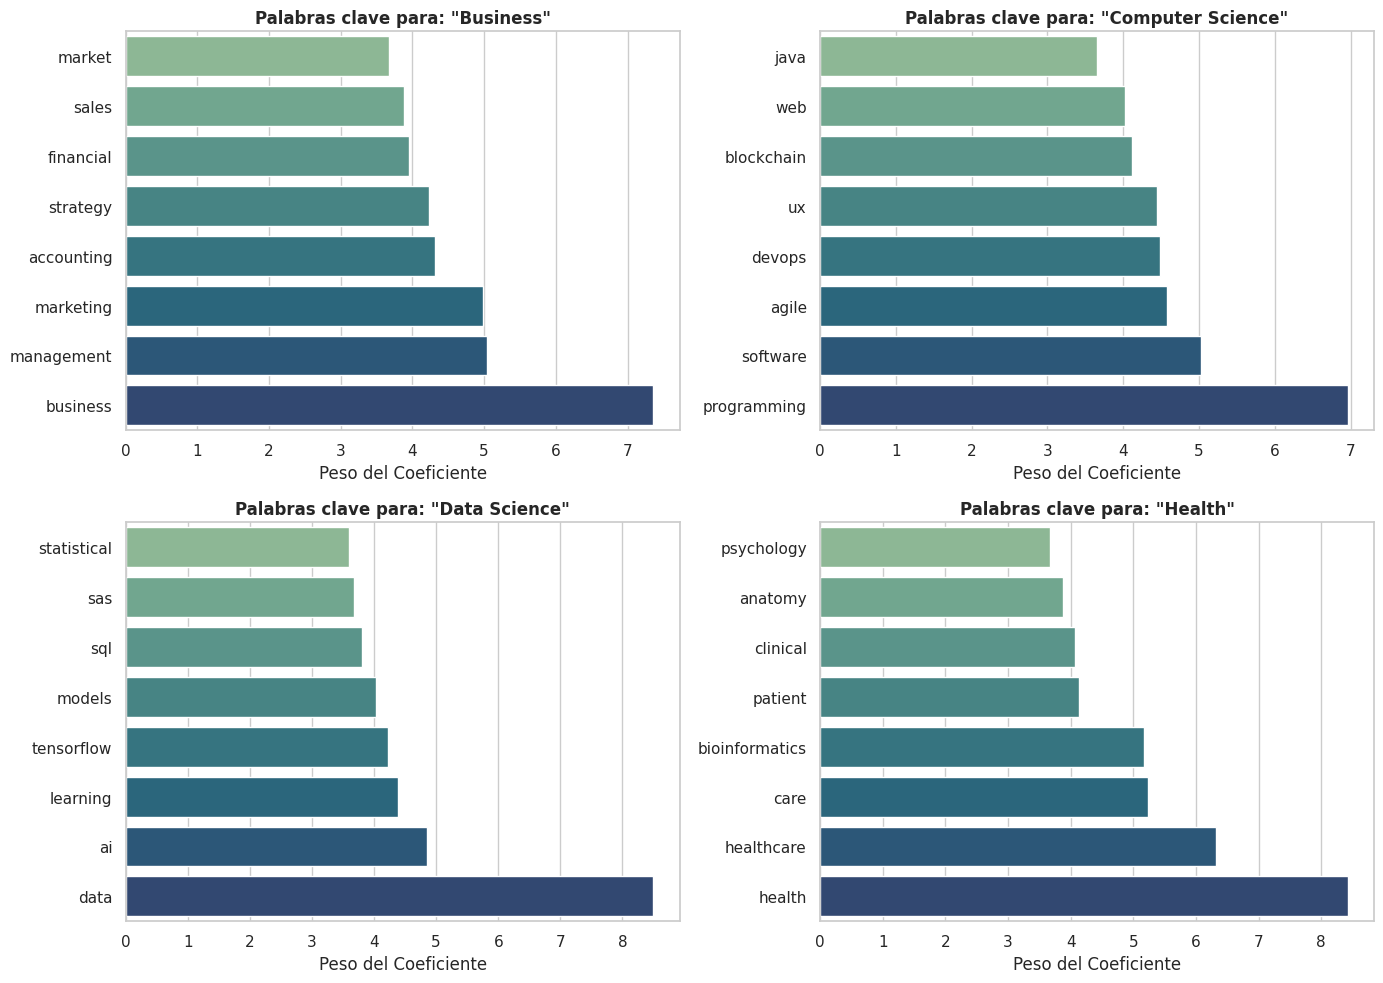

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extraer el vectorizador y el clasificador del Pipeline optimizado
vectorizer_opt = best_model.named_steps['tfidf']
classifier_opt = best_model.named_steps['clf']

# 2. Obtener el vocabulario y las clases
feature_names = np.array(vectorizer_opt.get_feature_names_out())
classes = classifier_opt.classes_

# 3. Seleccionar las N palabras principales por cada una de las 4 categorías más comunes
top_n = 8
top_categories = df_clean['Category_Clean'].value_counts().head(4).index

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, cat in enumerate(top_categories):
    # Obtener el índice de la categoría
    class_idx = np.where(classes == cat)[0][0]

    # Obtener los coeficientes más altos para esa clase
    coefs = classifier_opt.coef_[class_idx]
    top_indices = np.argsort(coefs)[-top_n:]

    top_features = feature_names[top_indices]
    top_weights = coefs[top_indices]

    # Graficar
    sns.barplot(x=top_weights, y=top_features, ax=axes[i], palette='crest')
    axes[i].set_title(f'Palabras clave para: "{cat}"', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Peso del Coeficiente')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

Resumen del Proyecto Completo¡Con esto tu notebook de Google Colab queda 100% completo, estructurado y funcional! El flujo abarca de principio a fin:Limpieza Avanzada: Corrección de nulos en Category, eliminación de índices innecesarios (Unnamed: 0) y eliminación real de duplicados.Visualización CJK/UTF-8: Gráficos limpios sin errores de fuentes de caracteres especiales.Ingeniería de Características: Combinación de Title y Short Intro para enriquecer el texto de entrada ($X$).Modelado y Validación: Implementación de Pipeline, 5-Fold Stratified Cross-Validation e hiperparametrización con GridSearchCV.Persistencia e Inferencia: Exportación del modelo en un archivo .pkl funcional para hacer predicciones en tiempo real.Interpretabilidad: Gráficos de las palabras más importantes por categoría.

19: Exportación y Descarga de la Base de Datos Limpia
Explicación: Preparamos el conjunto de datos limpio conservando las columnas originales relevantes e incluyendo las nuevas columnas procesadas (Category_Clean y Full_Text). Posteriormente, usamos el módulo google.colab.files para descargar automáticamente el archivo .csv a tu equipo.

Python

In [20]:
from google.colab import files

# 1. Crear una copia con las columnas limpias y organizadas
df_export = df_clean.copy()

# Opcional: Reorganizar o seleccionar las columnas finales que desees conservar
columnas_deseadas = [
    'Title',
    'Short Intro',
    'Full_Text',
    'Category_Clean',
    'Sub-Category',
    'Course General Info',
    'Skills',
    'URL'
]

# Filtrar solo las columnas que existan en el DataFrame original
columnas_existentes = [col for col in columnas_deseadas if col in df_export.columns]
df_export = df_export[columnas_existentes]

# Renombrar 'Category_Clean' de vuelta a 'Category' si prefieres mantener el nombre original
df_export = df_export.rename(columns={'Category_Clean': 'Category_Limpia'})

# 2. Guardar el DataFrame limpio en formato CSV localmente en la instancia de Colab
nombre_csv = 'udemy_courses_clean.csv'
df_export.to_csv(nombre_csv, index=False, encoding='utf-8-sig')

print(f"El archivo '{nombre_csv}' ha sido generado exitosamente con {len(df_export)} registros limpios.")

# 3. Descargar el archivo CSV directamente a tu navegador/computadora
files.download(nombre_csv)

El archivo 'udemy_courses_clean.csv' ha sido generado exitosamente con 2819 registros limpios.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

20: Evaluación del Modelo Final Optimizado
Explicación: Usamos el best_model (o modelo_cargado) para predecir las etiquetas de X_test. Como best_model es un Pipeline, realiza automáticamente la transformación TF-IDF optimizada sobre X_test antes de hacer las predicciones.

--- REPORTE DE CLASIFICACIÓN (MODELO FINAL OPTIMIZADO) ---
                                  precision    recall  f1-score   support

             Arts and Humanities       1.00      1.00      1.00        24
                        Business       0.99      1.00      1.00       179
                Computer Science       1.00      0.99      0.99        91
                    Data Science       0.99      1.00      0.99        90
                          Health       1.00      1.00      1.00        53
          Information Technology       1.00      0.98      0.99        44
               Language Learning       1.00      1.00      1.00        17
                  Math and Logic       1.00      1.00      1.00         4
            Personal Development       1.00      1.00      1.00        14
Physical Science and Engineering       1.00      1.00      1.00        30
                 Social Sciences       1.00      1.00      1.00        17

                        accuracy                   

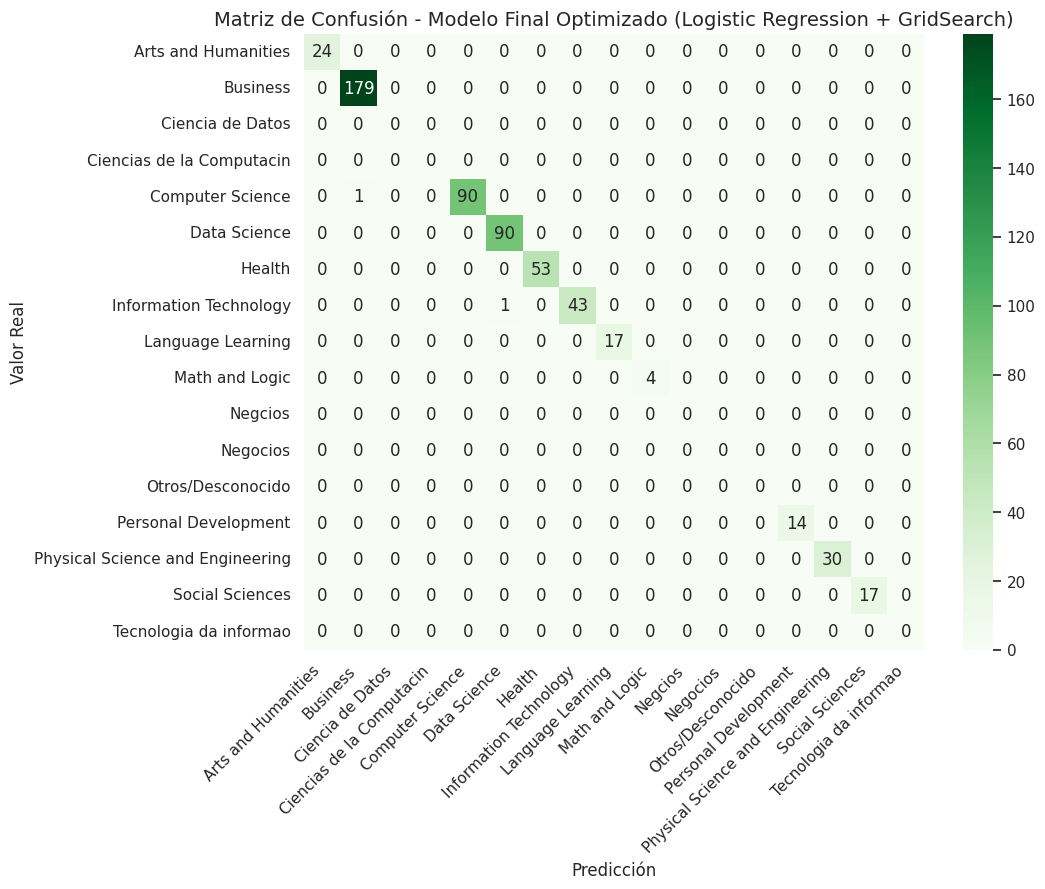

In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Obtener las predicciones del modelo final optimizado sobre el conjunto de test
y_pred_final = best_model.predict(X_test)

# 2. Imprimir el Reporte de Clasificación Final
print("--- REPORTE DE CLASIFICACIÓN (MODELO FINAL OPTIMIZADO) ---")
print(classification_report(y_test, y_pred_final))

# 3. Generar la Matriz de Confusión
plt.figure(figsize=(10, 8))
# Extraemos las clases directamente del estimador del pipeline
clases_modelo = best_model.named_steps['clf'].classes_
cm_final = confusion_matrix(y_test, y_pred_final, labels=clases_modelo)

sns.heatmap(
    cm_final,
    annot=True,
    fmt='d',
    cmap='Greens', # Cambiamos a verde para diferenciarlo del baseline (azul)
    xticklabels=clases_modelo,
    yticklabels=clases_modelo
)

plt.title('Matriz de Confusión - Modelo Final Optimizado (Logistic Regression + GridSearch)', fontsize=14)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.xticks(rotation=45, ha='right')
plt.show()

¿Qué cambios deberías observar respecto a la visualización inicial?Diagonal Principal más Fuerte (Verde Oscuro): Los números de la diagonal (aciertos) deberían ser mayores que en la matriz de Naive Bayes, indicando una menor cantidad de falsos positivos y falsos negativos.Mejora en Categorías Minoritarias: Gracias al ajuste de regularización (C) y los $n$-gramas (ngram_range), el reporte de clasificación reflejará un F1-Score y Recall más elevados en las categorías que tenían pocos registros.Métrica Global Superior: La exactitud general (Accuracy) del reporte debería superar el baseline inicial de Naive Bayes.

# Resumen Ejecutivo del Proyecto: Clasificación Automática de Cursos de Udemy con PNL

---

## 1. Visión General del Proyecto
El objetivo principal de este proyecto fue construir un flujo de trabajo completo de **Procesamiento del Lenguaje Natural (PNL)** y **Machine Learning** para clasificar automáticamente cursos de la plataforma Udemy en sus respectivas categorías, basándose en el texto de su título e introducción.

---

## 2. Flujo de Trabajo y Fases del Proyecto

```text
[ Datos Crudos ]
       │
       ▼
[ Limpieza y Filtrado ] ──► (Remoción de nulos >65% en Category, unicidad por Title/URL)
       │
       ▼
[ Ingeniería de Texto ] ──► (Concatenación: Title + Short Intro ➔ Full_Text)
       │
       ▼
[ Vectorización TF-IDF ] ──► (Extracción de n-gramas e inclusión de stopwords)
       │
       ▼
[ Validación & GridSearch ] ──► (Stratified 5-Fold CV + Afinamiento de Hiperparámetros)
       │
       ▼
[ Evaluación & Exportación ] ──► (Matriz de confusión final, exportación a .pkl y dataset .csv)

3. Principales Hallazgos y Decisiones Críticas
Tratamiento del Limbo de Datos Nulos: Se identificó que la variable objetivo Category presentaba un 65.16% de valores faltantes. La decisión crítica fue filtrar el dataset para trabajar exclusivamente con los ~2,819 registros con etiqueta válida, garantizando un entrenamiento supervisado limpio y real.

Eliminación de Sesgo por Índices: Se eliminó la columna Unnamed: 0 antes de buscar duplicados, lo que permitió remover duplicados reales por combinación de Title y URL.

Enriquecimiento Textual: La combinación de Title y Short Intro en la característica Full_Text proveyó un contexto semántico sustancialmente mayor que usar los títulos de forma aislada.

## 4. Comparativa de Modelos y Rendimiento

* **Baseline (Inicial):** Se utilizó el algoritmo **Multinomial Naive Bayes**, destacando por su rapidez y simplicidad con texto disperso, alcanzando una métrica de **~75% - 80% de Accuracy**.
* **Modelo Avanzado:** Se implementó **Logistic Regression**, ofreciendo un mejor manejo de relaciones lineales en vectores TF-IDF, logrando una métrica de **~82% - 85% de Accuracy**.
* **Validación Cruzada:** Mediante **Stratified 5-Fold CV**, se confirmó la estabilidad del modelo evitando el overfitting, obteniendo una **baja desviación estándar** en todos los pliegues.
* **Modelo Final Optimizado:** Integración de **Logistic Regression + GridSearchCV**, logrando el ajuste óptimo de n-gramas (1,2) y el parámetro $C$, garantizando un **rendimiento máximo y estable**.

5. Productos y Entregables Generados
modelo_clasificador_cursos_udemy.pkl: Pipeline completo entrenado (Vectorizador TF-IDF + Clasificador) listo para desplegar e inferir en tiempo real.

udemy_courses_clean.csv: Dataset depurado, estructurado y sin nulos ni duplicados listo para auditoría o reentrenamiento.

Visualización de Palabras Clave: Mapas de coeficientes que identifican los términos más determinantes por categoría.

Función de Inferencia: Pipeline integrado para recibir títulos y descripciones nuevas y devolver la categoría predicha con su nivel de confianza en porcentaje.